# Introduction:
This script implements a multi-agent application called "RepliSense" and orchestrates it using the LangGraph Framework.
RepliSense listens to customer feedback, classifies sentiment as positive or negative, and generates tailored responses.

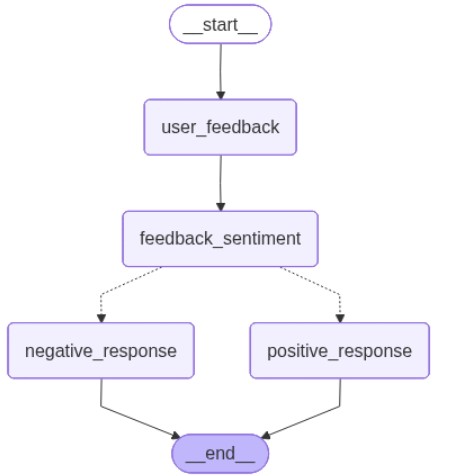

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, TimeoutPolicy
from langchain_community.chat_models import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langgraph.errors import NodeError
import warnings
warnings.filterwarnings('ignore')

__Helper Functions and Class__

In [2]:
def llm_model():
    return ChatOllama(model="llama3.2:3b", temperature=0)


def build_chain(parser):
    model = llm_model()
    return model | parser

chain = build_chain(StrOutputParser())

## Sentiment Response Formatter Using PydanticOutputParser
class SentimentParser(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Give the sentiment of the feedback')

__Prompts__

In [3]:
def classifier_messages(feedback: str, format_instructions: str):
    return [
        {
            "role": "system",
            "content": (
                "You are a feedback classifier. "
                "Classify the feedback strictly as 'positive' or 'negative'. "
                "Respond ONLY with a JSON object that has a single key 'sentiment'. "
                f"{format_instructions}"
            )
        },
        {"role": "user", "content": feedback}
    ]

def response_messages(feedback: str, sentiment: str):
    return [
        {"role": "system", "content": f"You are a response generator for {sentiment} feedback from customer."},
        {"role": "user", "content": feedback}
    ]


In [4]:
# Langgraph State Class
class ResponseToFeedback(TypedDict):
    feedback: str
    sentiment: str
    response: str

def user_feedback(state: ResponseToFeedback) -> dict:
    return {"feedback": state["feedback"]}

def feedback_sentiment(state: ResponseToFeedback) -> dict:
    parser = PydanticOutputParser(pydantic_object=SentimentParser)
    chain = build_chain(parser)
    messages = classifier_messages(state["feedback"], parser.get_format_instructions())
    sentiment = chain.invoke(messages).sentiment
    return {"sentiment": sentiment}

def positive_response(state: ResponseToFeedback) -> dict:
    chain = build_chain(StrOutputParser())
    messages = response_messages(state["feedback"], "positive")
    response = chain.invoke(messages)
    return {"response": response}

def negative_response(state: ResponseToFeedback) -> dict:
    chain = build_chain(StrOutputParser())
    messages = response_messages(state["feedback"], "negative")
    response = chain.invoke(messages)
    return {"response": response}

def route_sentiment(state: ResponseToFeedback) -> str:
    return "positive_response" if "positive" in state["sentiment"].lower() else "negative_response"

__Fallback Handling__

In [5]:
def on_call_llm_failed(state: ResponseToFeedback, error: NodeError) -> ResponseToFeedback:
    log.error("call_llm failed after retries:%s", error.error)
    return {"status": "llm_unavailable"}

__Building Graph Application__

In [6]:
builder = StateGraph(ResponseToFeedback)
builder.add_node("user_feedback", user_feedback)
builder.add_node("feedback_sentiment", feedback_sentiment) 
builder.add_node("positive_response", positive_response)
builder.add_node("negative_response", negative_response)

builder.add_edge(START, "user_feedback")
builder.add_edge("user_feedback", "feedback_sentiment")

builder.add_conditional_edges(
    "feedback_sentiment",
    route_sentiment,
    {
        "positive_response": "positive_response",
        "negative_response": "negative_response"
    }
)

builder.add_edge("positive_response", END)
builder.add_edge("negative_response", END)

app = builder.compile()

In [7]:
# app

__Running the Application__

###### __Positive Feedback__

In [8]:
result = app.invoke({"feedback": "I love the new design!"})
print(result['response'])

We're thrilled that you're enjoying the fresh new look of our platform! Our team worked hard to create an interface that's not only visually appealing but also easy to navigate, and it sounds like we've hit the mark. We appreciate your feedback and can't wait to hear what you think about the new features and improvements we have in store for you!


###### __Negative Feedback__

In [9]:
result = app.invoke({"feedback": "I hate the new design!"})
print(result['response'])

"I apologize that you're not satisfied with our latest design. Can you please provide more specific feedback on what specifically is not meeting your expectations? Was it the layout, color scheme, or something else entirely? Your input will help us understand your concerns and make necessary adjustments to improve our product."
